# 회귀기반 추천 시스템
사용자의 여행 특성과 방문지 정보를 입력으로 받아, 해당 방문지에 대한 예상 만족도를 예측하고 높은 순으로 추천한다. 즉 추천 문제를 만족도 예측 회귀 문제로 변환한 예시이다.

## 제주도 여행데이터

https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=data&dataSetSn=71584

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## AIHub 국내 여행로그 데이터 구조 이해

이 데이터는 여행자 개인 정보, 여행 스타일, 여행 동기, 방문지 정보, 이동수단, 만족도 등을 바탕으로
여행 분석, 만족도 예측, 추천 시스템 실습에 활용할 수 있는 데이터이다.  
공식 AIHub 설명에 따르면 제주도 및 도서지역 여행 로그를 기반으로 구축되었으며,
고지출 여행객 예측과 여행 장소 추천에 활용할 수 있도록 설계되었다. 

AIHub 원본은 여러 CSV 파일로 구성되지만,
현재 실습용 `travel.csv`는 그중 일부 변수를 정리한 학습용 테이블로 볼 수 있다.  
업로드된 `travel.csv`는 15개 컬럼으로 구성되어 있으며,
한 행(row)은 “특정 여행객의 특정 방문 경험” 또는 “여행객-방문지 관측치”로 이해하면 된다.

### 현재 travel.csv 주요 컬럼 해석

1. 여행객 기본 정보
- `GENDER`: 성별
- `AGE_GRP`: 연령대 코드

2. 여행 성향/선호 정보
- `TRAVEL_STYL_1` ~ `TRAVEL_STYL_8`: 여행 스타일 관련 응답값
  - 예: 자연 선호, 휴양 선호, 체험 선호 같은 여행 성향 점수/코드로 해석 가능
  - 값이 1~7 범위로 보이므로, 보통 선호도 척도 또는 순위형 응답으로 다룬다

3. 여행 목적/동행 정보
- `TRAVEL_MOTIVE_1`: 주요 여행 동기 코드
- `TRAVEL_COMPANIONS_NUM`: 동반자 수

4. 방문지/이동 정보
- `VISIT_AREA_NM`: 방문 장소명
- `MVMN_NM`: 이동수단명
  - 예: 자가용, 대중교통 등

5. 만족도(타깃으로 쓰기 좋은 값)
- `DGSTFN`: 만족도 점수
  - 1~5 값으로 보이며, 방문 경험에 대한 만족도 라벨로 해석할 수 있다

### 이 파일을 어떻게 바라보면 좋은가?

이 데이터는 크게 보면 다음 구조이다.

- 이 사람은 어떤 여행자였는가?  
  → `GENDER`, `AGE_GRP`, `TRAVEL_STYL_*`, `TRAVEL_MOTIVE_1`, `TRAVEL_COMPANIONS_NUM`

- 어디를 어떻게 방문했는가?  
  → `VISIT_AREA_NM`, `MVMN_NM`

- 그 결과 만족했는가?  
  → `DGSTFN`

즉 이 테이블은  
“여행자 특성 + 방문지 정보 → 만족도 예측”  
또는  
“여행자 특성 + 방문지 특성 → 추천”  
형태의 실습에 적합하다.

### AIHub 원본 데이터셋 전체 관점

공식 페이지 기준 원본 데이터셋은 여행객 마스터, 여행 정보, 이동 내역, 활동 내역, 소비 내역, 방문지 정보, 사진, POI 등 여러 CSV 파일로 구성된다.  
즉 `travel.csv`는 원본 전체 중 일부 핵심 변수를 뽑아 모델링하기 쉽게 정리한 축약형 데이터로 이해하면 된다. 

## 데이터 확인

In [2]:
travel_df = pd.read_csv('data/travel.csv')
travel_df.head()

,GENDER,AGE_GRP,TRAVEL_STYL_1,TRAVEL_STYL_2,TRAVEL_STYL_3,TRAVEL_STYL_4,TRAVEL_STYL_5,TRAVEL_STYL_6,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_MOTIVE_1,TRAVEL_COMPANIONS_NUM,VISIT_AREA_NM,MVMN_NM,DGSTFN
0,남,30.0,1.0,4.0,2.0,2.0,6.0,2.0,2.0,7.0,3.0,3.0,미스틱3도,자가용,5.0
1,남,20.0,4.0,1.0,5.0,1.0,1.0,4.0,1.0,6.0,3.0,1.0,에스제이렌트카,대중교통 등,4.0
2,여,50.0,4.0,1.0,2.0,4.0,3.0,3.0,2.0,3.0,1.0,3.0,법환식당,대중교통 등,5.0
3,남,30.0,1.0,1.0,1.0,5.0,6.0,3.0,5.0,7.0,7.0,3.0,에코랜드호텔,자가용,5.0
4,여,20.0,5.0,3.0,3.0,3.0,3.0,3.0,3.0,5.0,1.0,2.0,윤스타피자앤파스타,자가용,4.0


In [3]:
travel_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34572 entries, 0 to 34571
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GENDER                 34572 non-null  str    
 1   AGE_GRP                34572 non-null  float64
 2   TRAVEL_STYL_1          34572 non-null  float64
 3   TRAVEL_STYL_2          34572 non-null  float64
 4   TRAVEL_STYL_3          34572 non-null  float64
 5   TRAVEL_STYL_4          34572 non-null  float64
 6   TRAVEL_STYL_5          34572 non-null  float64
 7   TRAVEL_STYL_6          34572 non-null  float64
 8   TRAVEL_STYL_7          34572 non-null  float64
 9   TRAVEL_STYL_8          34572 non-null  float64
 10  TRAVEL_MOTIVE_1        34572 non-null  float64
 11  TRAVEL_COMPANIONS_NUM  34572 non-null  float64
 12  VISIT_AREA_NM          34572 non-null  str    
 13  MVMN_NM                34572 non-null  str    
 14  DGSTFN                 34572 non-null  float64
dtypes: float64(12

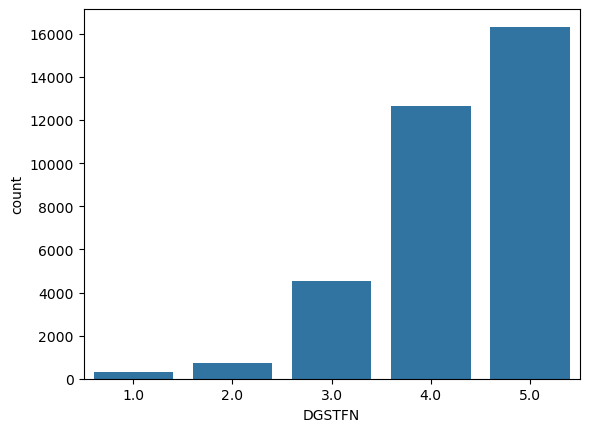

In [4]:
# 타깃 정보 확인
sns.countplot(x='DGSTFN', data=travel_df)
plt.show()

## 데이터 변환

In [5]:
# 범주 코드처럼 사용하는 컬럼들의 자료형을 정수형으로 변환
# - CSV를 읽는 과정에서 값이 1.0, 2.0 같은 float로 들어올 수 있다.
# - 이 컬럼들은 연속형 수치라기보다 범주를 나타내는 코드이므로 int로 정리한다.
cat_code_cols = [
    'AGE_GRP', 'TRAVEL_STYL_1', 'TRAVEL_STYL_2', 'TRAVEL_STYL_3',
    'TRAVEL_STYL_4', 'TRAVEL_STYL_5', 'TRAVEL_STYL_6', 'TRAVEL_STYL_7',
    'TRAVEL_STYL_8', 'TRAVEL_MOTIVE_1', 'TRAVEL_COMPANIONS_NUM'
]
travel_df[cat_code_cols] = travel_df[cat_code_cols].astype(int)

In [8]:
travel_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34572 entries, 0 to 34571
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GENDER                 34572 non-null  str    
 1   AGE_GRP                34572 non-null  int32  
 2   TRAVEL_STYL_1          34572 non-null  int32  
 3   TRAVEL_STYL_2          34572 non-null  int32  
 4   TRAVEL_STYL_3          34572 non-null  int32  
 5   TRAVEL_STYL_4          34572 non-null  int32  
 6   TRAVEL_STYL_5          34572 non-null  int32  
 7   TRAVEL_STYL_6          34572 non-null  int32  
 8   TRAVEL_STYL_7          34572 non-null  int32  
 9   TRAVEL_STYL_8          34572 non-null  int32  
 10  TRAVEL_MOTIVE_1        34572 non-null  int32  
 11  TRAVEL_COMPANIONS_NUM  34572 non-null  int32  
 12  VISIT_AREA_NM          34572 non-null  str    
 13  MVMN_NM                34572 non-null  str    
 14  DGSTFN                 34572 non-null  float64
dtypes: float64(1)

In [7]:
travel_df.describe()

,AGE_GRP,TRAVEL_STYL_1,TRAVEL_STYL_2,TRAVEL_STYL_3,TRAVEL_STYL_4,TRAVEL_STYL_5,TRAVEL_STYL_6,TRAVEL_STYL_7,TRAVEL_STYL_8,TRAVEL_MOTIVE_1,TRAVEL_COMPANIONS_NUM,DGSTFN
count,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000,34572.000000
mean,28.470149,2.941137,2.405126,2.567801,3.332755,3.628312,3.657497,3.998814,4.877126,3.174679,1.489008,4.271144
std,9.096760,1.585247,1.520238,1.523111,1.587388,1.755299,1.655809,1.959919,1.784733,2.437807,1.621452,0.835598
min,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,20.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,4.000000,1.000000,0.000000,4.000000
50%,30.000000,3.000000,2.000000,2.000000,3.000000,4.000000,4.000000,4.000000,5.000000,2.000000,1.000000,4.000000
75%,30.000000,4.000000,3.000000,4.000000,4.000000,5.000000,5.000000,6.000000,6.000000,4.000000,2.000000,5.000000
max,60.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,10.000000,20.000000,5.000000


In [9]:
# 동행자 수는 추천 결과에 영향을 줄 수 있는 변수이므로, 값의 범위와 분포를 확인
travel_df['TRAVEL_COMPANIONS_NUM'].value_counts()

TRAVEL_COMPANIONS_NUM
1     13864
0      9100
3      4749
2      4040
4      1241
5       709
6       287
7       216
8       154
9        91
10       39
12       31
13       19
17       14
14       13
11        4
20        1
Name: count, dtype: int64

In [10]:
# 범주형 데이터 컬럼명
cat_columns = travel_df.columns[:-1].tolist()
cat_columns

['GENDER',
 'AGE_GRP',
 'TRAVEL_STYL_1',
 'TRAVEL_STYL_2',
 'TRAVEL_STYL_3',
 'TRAVEL_STYL_4',
 'TRAVEL_STYL_5',
 'TRAVEL_STYL_6',
 'TRAVEL_STYL_7',
 'TRAVEL_STYL_8',
 'TRAVEL_MOTIVE_1',
 'TRAVEL_COMPANIONS_NUM',
 'VISIT_AREA_NM',
 'MVMN_NM']

In [11]:
# 데이터 분할
from sklearn.model_selection import train_test_split

X = travel_df[cat_columns]
y = travel_df['DGSTFN']

# 만족도 값이 1~5의 이산 점수이므로 train/test에서도 각 점수 비율이 비슷하게 유지되도록 stratify를 사용한다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(27657, 14) (27657,)
(6915, 14) (6915,)


In [12]:
# 모델 학습
from catboost import Pool, CatBoostRegressor

train_pool = Pool(X_train, y_train, cat_features=cat_columns)
test_pool = Pool(X_test, y_test, cat_features=cat_columns)

cat_reg = CatBoostRegressor(
    n_estimators=5000,
    depth=5,
    learning_rate=0.01,
    loss_function='RMSE',
    eval_metric='RMSE'
)

cat_reg.fit(train_pool, eval_set=[test_pool], verbose=50, early_stopping_rounds=100)

0:	learn: 0.8354854	test: 0.8351313	best: 0.8351313 (0)	total: 204ms	remaining: 17m
50:	learn: 0.8243505	test: 0.8223615	best: 0.8223615 (50)	total: 2.5s	remaining: 4m 2s
100:	learn: 0.8170003	test: 0.8139389	best: 0.8139389 (100)	total: 4.95s	remaining: 4m
150:	learn: 0.8111536	test: 0.8066374	best: 0.8066374 (150)	total: 7.71s	remaining: 4m 7s
200:	learn: 0.8066524	test: 0.8014470	best: 0.8014470 (200)	total: 10.6s	remaining: 4m 13s
250:	learn: 0.8014947	test: 0.7954218	best: 0.7954218 (250)	total: 13.6s	remaining: 4m 16s
300:	learn: 0.7978908	test: 0.7914475	best: 0.7914475 (300)	total: 16.3s	remaining: 4m 14s
350:	learn: 0.7949451	test: 0.7880587	best: 0.7880587 (350)	total: 19.2s	remaining: 4m 14s
400:	learn: 0.7924870	test: 0.7853802	best: 0.7853802 (400)	total: 21.9s	remaining: 4m 11s
450:	learn: 0.7905963	test: 0.7835670	best: 0.7835670 (450)	total: 24.7s	remaining: 4m 9s
500:	learn: 0.7889289	test: 0.7818862	best: 0.7818862 (500)	total: 27.6s	remaining: 4m 7s
550:	learn: 0.787

In [14]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

pred = cat_reg.predict(X_test)
print('Test RMSE:', root_mean_squared_error(y_test, pred))
print('Test MAE:', mean_absolute_error(y_test, pred))

Test RMSE: 0.767412929264987
Test MAE: 0.5738170232236688


dict_keys(['learn', 'validation'])


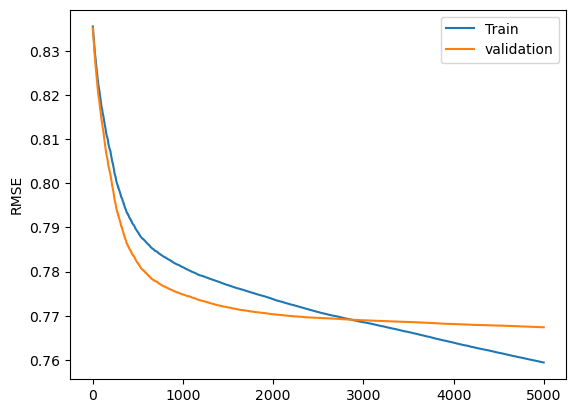

In [13]:
# 시각화
evals_result = cat_reg.get_evals_result()
print(evals_result.keys())  # ['learn', 'validation']

plt.plot(evals_result['learn']['RMSE'], label='Train')
plt.plot(evals_result['validation']['RMSE'], label='validation')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [15]:
# 특성 중요도
feature_importances_df = pd.DataFrame({
    'columns' : X_train.columns,
    'Importance' : cat_reg.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importances_df

,columns,Importance
12,VISIT_AREA_NM,13.378476
9,TRAVEL_STYL_8,11.123006
6,TRAVEL_STYL_5,9.085270
7,TRAVEL_STYL_6,8.770674
5,TRAVEL_STYL_4,8.291856
10,TRAVEL_MOTIVE_1,7.986836
1,AGE_GRP,7.809550
8,TRAVEL_STYL_7,7.791993
2,TRAVEL_STYL_1,7.480362
3,TRAVEL_STYL_2,7.355418


In [16]:
# 예측
print('입력 데이터 : ', X_test.iloc[0])
print('실제 만족도 : ', y_test.iloc[0])
print('예측 만족도 : ', cat_reg.predict(X_test.iloc[[0]]))

입력 데이터 :  GENDER                          남
AGE_GRP                        60
TRAVEL_STYL_1                   1
TRAVEL_STYL_2                   1
TRAVEL_STYL_3                   5
TRAVEL_STYL_4                   3
TRAVEL_STYL_5                   1
TRAVEL_STYL_6                   5
TRAVEL_STYL_7                   1
TRAVEL_STYL_8                   6
TRAVEL_MOTIVE_1                 2
TRAVEL_COMPANIONS_NUM           1
VISIT_AREA_NM            로얄엠포리움호텔
MVMN_NM                       자가용
Name: 28442, dtype: object
실제 만족도 :  3.0
예측 만족도 :  [3.56623422]


## 추천 함수

학습한 회귀 모델을 추천 방식으로 확장해본다.

사용자 정보는 고정하고, 방문지 후보만 하나씩 바꿔 넣어
각 지역에 대한 예상 만족도를 계산한다.
그 후 예측 만족도가 높은 지역을 상위 추천 결과로 반환한다.

흐름
- 사용자 입력 정보 준비
- 후보 방문지별 만족도 예측
- 예측값이 높은 상위 n개 지역 추천

In [17]:
# 방문지 정보
visit_areas = travel_df['VISIT_AREA_NM'].unique()
visit_areas

<StringArray>
[        '미스틱3도',       '에스제이렌트카',          '법환식당',        '에코랜드호텔',
     '윤스타피자앤파스타',      '서정리역 1호선',          '동문식당',          '해녀식당',
         '알맞은시간',          '애월온기',
 ...
        '제주초계한우',        '숲속의컨벤션',  '제주신화월드 S BAR',         '월미전망대',
         '네이처파크',           '고옥정',  '네스트호텔 쿤스트라운지',        '제이스바버샵',
 '블라제리조트 전기차충전소',           '미미슈']
Length: 10711, dtype: str

In [ ]:
# 추천 함수
def recommend_visit_area(user_input, topn=10):
    '''
    사용자 정보와 방문지 후보를 조합해
    만족도 예측 값이 높은 상위 지역 topn개를 반환하는 함수
    '''
    
    rows = []
    
    # 사용자 정보에 방문지 후보를 하나씩 넣어 추천 후보 행 생성
    for area in visit_areas:
        row = user_input.copy()
        row['VISIT_AREA_NM'] = area
        rows.append(row)
        
    # dict 리스트 -> DataFrame
    candidate_df = pd.DataFrame(rows)
    
    # 학습 때 사용한 컬럼 순서로 정렬 (모델에 전달하기 위해)
    candidate_df = candidate_df[X_train.columns]
    
    # 각 후보 방문지의 만족도 예측
    candidate_df['dgstfn_pred'] = cat_reg.predict(candidate_df)
    
    # 필요한 컬럼만 선택
    result_df = candidate_df[['VISIT_AREA_NM', 'dgstfn_pred']]
    
    # 예측 값 기준 내림차순 정렬 후 상위 topn 반환
    result_df = result_df.sort_values('dgstfn_pred', ascending=False).head(topn)
    
    return result_df
    

In [20]:
# 사용자 정보
user_input = {
    'GENDER' : '남',
    'AGE_GRP' : 60,
    'TRAVEL_STYL_1' : 1,
    'TRAVEL_STYL_2' : 1,
    'TRAVEL_STYL_3' : 5,
    'TRAVEL_STYL_4' : 3,
    'TRAVEL_STYL_5' : 1,
    'TRAVEL_STYL_6' : 5,
    'TRAVEL_STYL_7' : 1,
    'TRAVEL_STYL_8' : 6,
    'TRAVEL_MOTIVE_1' : 2,
    'TRAVEL_COMPANIONS_NUM' : 1,
    'MVMN_NM' : '자가용'
}

recommend_visit_area(user_input)

,VISIT_AREA_NM,dgstfn_pred
676,파라다이스시티,4.256868
129,스누피가든,4.241525
2300,그랜드하얏트제주,4.229887
324,호텔샌드,4.221503
1014,비양놀,4.213370
406,숙성도 노형점,4.208761
2314,회춘 애월점,4.205415
614,사려니숲길,4.201814
1807,그랜드조선제주 아리아,4.201526
53,울산공항,4.200902
